# M2.2 — Final comparison on the test set

This notebook carries out rules 2 and 4 of [03_core_model_iterations.ipynb](03_core_model_iterations.ipynb): the
**test set is used once**, to compare the M2.1 baseline with the final candidate. Nothing is changed after looking at it.

- **Baseline (M2.1):** XGBoost, engineered features, J1 hyper-parameters, decision threshold = max F1 on validation.
- **Final candidate:** whatever survived rules 1–3 in notebook 03. That is **iteration 2** (the same model, with a
  threshold chosen on validation by expected cost at 100 units per alert); iterations 1 and 3 were reverted. The notebook
  checks this against the experiment log instead of assuming it.

The test set holds 1,232 frauds, so a difference could be noise. Rule 4 uses a **paired Poisson bootstrap**: the test
rows are re-weighted 1,000 times with Poisson(1) weights, the same weights for both candidates, and the 95% interval of
the difference is reported (the same method as J1, notebook 01 §6.5). It is applied to PR-AUC (rule 4) and to expected
cost, since cost is where iteration 2 claimed a gain.

## 1. Setup, baseline refit, and the final candidate

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import average_precision_score

ROOT = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
sys.path.insert(0, str(ROOT))

from fraud.data import SEED, load_paysim, scope_transfer_cashout, split_70_15_15
from fraud.features import make_features
from fraud.metrics import (PRIMARY_REVIEW_COST, REVIEW_COSTS, WeightedAP, best_cost_threshold, best_f1_threshold,
                           evaluate, expected_cost, missed_amount)
from fraud.model import baseline_params, fit_xgb

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

d = scope_transfer_cashout(load_paysim())
X, RAW, ENG = make_features(d)
y = d["isFraud"].to_numpy()
amount = d["amount"].to_numpy()
train_idx, val_idx, test_idx = split_70_15_15(y)
y_val, y_test = y[val_idx], y[test_idx]
amount_val, amount_test = amount[val_idx], amount[test_idx]

In [2]:
model, secs = fit_xgb(X.iloc[train_idx][ENG], y[train_idx], X.iloc[val_idx][ENG], y_val, baseline_params())
val_score = model.predict_proba(X.iloc[val_idx][ENG])[:, 1]
test_score = model.predict_proba(X.iloc[test_idx][ENG])[:, 1]
f1_thr = best_f1_threshold(y_val, val_score)

# The baseline must be the J1 model: same test numbers as the committed comparison.
committed = pd.read_csv(ROOT / "reports" / "model_comparison.csv").set_index("model").loc["XGBoost"]
row = evaluate("baseline", y_test, test_score, f1_thr)
assert abs(row["PR-AUC"] - committed["PR-AUC"]) < 5e-4 and row["FN"] == committed["FN"] and row["FP"] == committed["FP"]
print(f"baseline refit: {model.best_iteration + 1} trees, threshold {f1_thr:.4f}; test PR-AUC {row['PR-AUC']:.4f}, FN {row['FN']}, FP {row['FP']} (matches J1)")

baseline refit: 117 trees, threshold 0.5057; test PR-AUC 0.9972, FN 4, FP 0 (matches J1)


In [3]:
# The final candidate, read from the experiment log. Only iteration 2 (a threshold change on the same model) may have been kept.
log = pd.read_csv(ROOT / "reports" / "m2_2" / "experiment_log.csv").set_index("iteration")
kept = [int(i) for i in log.index[log["decision"] == "keep"]]
assert kept == [2], f"the kept iterations are {kept}; this notebook only knows how to evaluate iteration 2 on the baseline model"
cost_thr = best_cost_threshold(y_val, amount_val, val_score, PRIMARY_REVIEW_COST)
assert abs(cost_thr - log.loc[2, "threshold"]) < 1e-9, "the threshold in the log is not the one recomputed here"
print(f"kept iterations: {kept}. Final candidate = baseline model with the minimum-cost threshold {cost_thr:.4f} (max-F1 threshold was {f1_thr:.4f}).")

kept iterations: [2]. Final candidate = baseline model with the minimum-cost threshold 0.0406 (max-F1 threshold was 0.5057).


## 2. Test-set operating points
The third row is the final candidate's model at the *baseline's* threshold, so the effect of the threshold change can be
read on its own. (The two models are the same, so that row equals the baseline.)

In [4]:
operating_points = {"baseline (M2.1)": f1_thr, "final candidate (min-cost threshold)": cost_thr}


def summary(thr):
    flagged = test_score >= thr
    row = evaluate("x", y_test, test_score, thr)
    out = {"PR-AUC": row["PR-AUC"], "threshold": thr, "alerts": int(flagged.sum()), "missed frauds": row["FN"],
           "false alarms": row["FP"], "precision": row["precision"], "recall": row["recall"],
           "missed amount": missed_amount(y_test, amount_test, flagged)}
    for c in REVIEW_COSTS:
        out[f"cost @ {c}"] = expected_cost(y_test, amount_test, flagged, c)
    return out


final_tbl = pd.DataFrame({name: summary(thr) for name, thr in operating_points.items()}).T
display(final_tbl.style.format({"PR-AUC": "{:.4f}", "threshold": "{:.4f}", "precision": "{:.3f}", "recall": "{:.4f}"})
        .format("{:,.0f}", subset=["alerts", "missed frauds", "false alarms", "missed amount", *[f"cost @ {c}" for c in REVIEW_COSTS]]))
final_tbl.reset_index(names="operating point").to_csv(ROOT / "reports" / "m2_2" / "final_comparison.csv", index=False)

,PR-AUC,threshold,alerts,missed frauds,false alarms,precision,recall,missed amount,cost @ 10,cost @ 100,cost @ 1000
baseline (M2.1),0.9972,0.5057,"1,228",4,0,1.000,0.9968,"822,153","834,433","944,953","2,050,153"
final candidate (min-cost threshold),0.9972,0.0406,"1,816",4,588,0.676,0.9968,"822,153","840,313","1,003,753","2,638,153"


## 3. Paired bootstrap (rule 4)

In [5]:
base_flag, final_flag = test_score >= f1_thr, test_score >= cost_thr
fraud_money = amount_test * (y_test == 1)
ap = WeightedAP(y_test, test_score)
assert abs(ap(np.ones(len(y_test))) - average_precision_score(y_test, test_score)) < 1e-9   # same check as J1

rng = np.random.default_rng(SEED)
B = 1000
d_prauc = np.empty(B)
d_cost = {c: np.empty(B) for c in REVIEW_COSTS}
for b in range(B):
    w = rng.poisson(1.0, len(y_test)).astype(float)               # one weight per test row, shared by both candidates
    d_prauc[b] = ap(w) - ap(w)                                    # same scores, so this is exactly 0 (kept for the paired form)
    for c in REVIEW_COSTS:
        cost_base = (w * fraud_money * ~base_flag).sum() + c * (w * base_flag).sum()
        cost_final = (w * fraud_money * ~final_flag).sum() + c * (w * final_flag).sum()
        d_cost[c][b] = cost_final - cost_base                      # negative = the final candidate is cheaper


def interval(v):
    return tuple(np.percentile(v, [2.5, 97.5]))


boot_rows = [{"quantity": "PR-AUC (final - baseline)", "observed": 0.0, "95% low": interval(d_prauc)[0],
              "95% high": interval(d_prauc)[1], "final cheaper in": np.nan}]
for c in REVIEW_COSTS:
    obs = final_tbl.iloc[1][f"cost @ {c}"] - final_tbl.iloc[0][f"cost @ {c}"]
    lo, hi = interval(d_cost[c])
    boot_rows.append({"quantity": f"expected cost @ {c} (final - baseline)", "observed": obs, "95% low": lo, "95% high": hi,
                      "final cheaper in": float((d_cost[c] < 0).mean())})
boot = pd.DataFrame(boot_rows)
display(boot.style.format({"observed": "{:,.0f}", "95% low": "{:,.0f}", "95% high": "{:,.0f}", "final cheaper in": "{:.1%}"}, na_rep="n/a").hide(axis="index"))
boot.to_csv(ROOT / "reports" / "m2_2" / "final_bootstrap.csv", index=False)

quantity,observed,95% low,95% high,final cheaper in
PR-AUC (final - baseline),0,0,0,n/a
expected cost @ 10 (final - baseline),"5,880","5,400","6,320",0.0%
expected cost @ 100 (final - baseline),"58,800","54,000","63,200",0.0%
expected cost @ 1000 (final - baseline),"588,000","540,000","632,000",0.0%


In [6]:
c_obs = final_tbl.iloc[1][f"cost @ {PRIMARY_REVIEW_COST}"] - final_tbl.iloc[0][f"cost @ {PRIMARY_REVIEW_COST}"]
c_lo, c_hi = interval(d_cost[PRIMARY_REVIEW_COST])
if c_hi < 0:
    cost_verdict = "The interval is entirely below 0: **a measurable saving.**"
elif c_lo > 0:
    cost_verdict = "The interval is entirely above 0: **the final candidate is measurably MORE expensive than the baseline.**"
else:
    cost_verdict = "The interval includes 0: **no measurable difference.**"
display(Markdown(
    "- **Rule 4, PR-AUC:** the two candidates use the same scores, so the PR-AUC difference is exactly 0 in every resample. "
    "**No change in PR-AUC.** The threshold change cannot move a threshold-free metric.\n"
    f"- **Expected cost at {PRIMARY_REVIEW_COST} units per alert:** change {c_obs:+,.0f}, 95% interval [{c_lo:+,.0f}, {c_hi:+,.0f}]. {cost_verdict}"))

- **Rule 4, PR-AUC:** the two candidates use the same scores, so the PR-AUC difference is exactly 0 in every resample. **No change in PR-AUC.** The threshold change cannot move a threshold-free metric.
- **Expected cost at 100 units per alert:** change +58,800, 95% interval [+54,000, +63,200]. The interval is entirely above 0: **the final candidate is measurably MORE expensive than the baseline.**

## 4. Why did the cost-based threshold not help?
Diagnosis only: the test errors below are looked at to understand the result, and nothing is changed because of them.

In [7]:
missed = np.flatnonzero((y_test == 1) & ~base_flag)
order_desc = np.sort(test_score)[::-1]
diag = pd.DataFrame({
    "amount": amount_test[missed],
    "score": test_score[missed],
    "alerts needed to catch it": [int((test_score > test_score[i]).sum()) + 1 for i in missed],
}).sort_values("score", ascending=False)
display(diag.style.format({"amount": "{:,.0f}", "score": "{:.4f}", "alerts needed to catch it": "{:,}"}).hide(axis="index"))
print(f"alerts raised: baseline {int(base_flag.sum()):,}, final candidate {int(final_flag.sum()):,}; "
      f"frauds caught: baseline {int(((y_test == 1) & base_flag).sum()):,}, final candidate {int(((y_test == 1) & final_flag).sum()):,}")

amount,score,alerts needed to catch it
"181,728",0.0338,"2,486"
"123,195",0.0091,"64,105"
"314,252",0.0076,"91,160"
"202,979",0.0048,"378,468"


alerts raised: baseline 1,228, final candidate 1,816; frauds caught: baseline 1,228, final candidate 1,228


## 5. The cost curve, validation next to test
Expected cost against the number of alerts raised (highest scores first), at 100 units per alert, zoomed to the range
where the two operating points sit. Left: the validation set, where the threshold was chosen. Right: the test set, where
the same threshold is applied unchanged. Each step down in a curve is one more fraud caught.

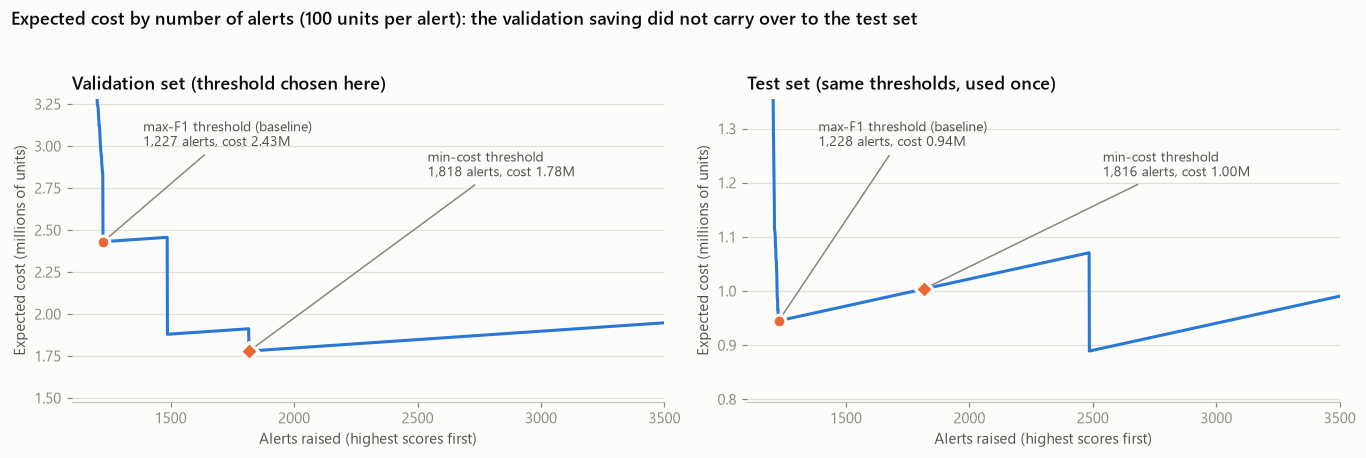

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Same chart style as the J1 notebook (notebook 01, cell 4): one palette, thin marks, recessive grid.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 11.5,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "lines.linewidth": 2, "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "figure.dpi": 110,
})


def cost_curve(y_part, amount_part, score_part, k_max=3500):
    """Expected cost (millions) if the top-k scored rows are flagged, for k = 1 .. k_max."""
    order = np.argsort(-score_part, kind="stable")
    caught = np.cumsum((amount_part * y_part)[order])
    k = np.arange(1, k_max + 1)
    return k, (caught[-1] - caught[:k_max] + PRIMARY_REVIEW_COST * k) / 1e6


panels = [("Validation set (threshold chosen here)", y_val, amount_val, val_score),
          ("Test set (same thresholds, used once)", y_test, amount_test, test_score)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, (title, y_p, a_p, s_p) in zip(axes, panels):
    k, cost = cost_curve(y_p, a_p, s_p)
    lo_k = 1100                                  # zoom: the curve is far higher (tens of millions) before this point
    ax.plot(k[lo_k:], cost[lo_k:], color=BLUE)
    op_costs = []
    for label, thr, marker, text_xy in (("max-F1 threshold (baseline)", f1_thr, "o", (0.12, 0.88)),
                                        ("min-cost threshold", cost_thr, "D", (0.60, 0.78))):
        n_alerts = int((s_p >= thr).sum())
        c_now = cost[n_alerts - 1]
        op_costs.append(c_now)
        ax.scatter([n_alerts], [c_now], s=70, marker=marker, color=ORANGE, edgecolor=SURFACE, linewidth=2, zorder=5)
        ax.annotate(f"{label}\n{n_alerts:,} alerts, cost {c_now:.2f}M", (n_alerts, c_now), xytext=text_xy,
                    textcoords="axes fraction", color=INK_2, fontsize=9, va="center",
                    arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 1})
    ax.set_xlim(lo_k, k[-1])
    y_lo, y_hi = cost[lo_k:].min(), max(op_costs) * 1.35
    ax.set_ylim(y_lo - 0.2 * (y_hi - y_lo), y_hi)   # the steep start of the curve is clipped at the top
    ax.set_xlabel("Alerts raised (highest scores first)")
    ax.set_ylabel("Expected cost (millions of units)")
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
fig.suptitle(f"Expected cost by number of alerts ({PRIMARY_REVIEW_COST} units per alert): the validation saving did not carry over to the test set",
             x=0.01, ha="left", fontsize=12, fontweight="semibold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(ROOT / "reports" / "figures" / "m2_2_cost_vs_alerts.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Reading the result

- **PR-AUC: no change, and none was on offer.** On the test set the baseline scores 0.9972 (4 of 1,232 frauds missed, 0
  false alarms), the ceiling discussed in notebook 03. The final candidate has the same scores, so the paired
  difference is exactly 0. The iterations that could have moved PR-AUC moved it by +0.00012 (iteration 1) and −0.00006
  (iteration 3) on validation, against a noise floor of σ = 0.00026.
- **Cost: the validation saving did not carry over, and the candidate is worse.** At the cost-chosen threshold (0.0406)
  the test set raises 588 more alerts than the baseline and catches no extra fraud: 4 missed in both, the same 822,153
  of fraud money in both. Expected cost at 100 units per alert rises from 944,953 to 1,003,753 (+58,800; 95% bootstrap
  interval +54,000 to +63,200), and it is higher at all three review costs. The bootstrap interval is narrow because the
  two candidates catch exactly the same frauds; all the difference is the 588 extra alerts.
- **Why.** The four frauds the baseline misses on test score 0.0338, 0.0091, 0.0076 and 0.0048. The threshold chosen on
  validation (0.0406) sits just above the best of them; catching that one takes 2,486 alerts, catching the others takes
  64,000 to 378,000. On validation, two of the five misses happened to score 0.041 and 0.049, just over where the
  threshold landed. So the threshold was decided by two transactions. The cross-fitted check in notebook 03 halved the
  claimed saving but still predicted one: cross-fitting guards against fitting the threshold to the exact rows it is
  judged on, not against a handful of frauds whose scores happened to fall in the same narrow band in both halves.
- **What to ship.** The rules written before the iterations keep iteration 2, so "final candidate" above is iteration 2
  as the rules defined it. **After seeing this result, the judgment (not a rule) is not to adopt the cost-based
  threshold: keep the baseline's max-F1 threshold.** That decision was made with the test result in view, so it is
  recorded as such and nothing has been re-tuned because of it. The cost-based operating point stays as a documented
  experiment that did not generalise.
- **What it would take to do this properly.** Choosing a threshold from 5 misses cannot work. Options for later: pool
  train and validation and score them out-of-fold, so the threshold is chosen from thousands of frauds rather than 1,232
  (still only a few dozen misses); or set the operating point by policy (for example "alert on at least this share of
  fraud") instead of learning it from a few errors.